In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import random

## EDA

In [5]:
##NUEVOS PACIENTES

# Cargar datos
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/sgonzalez/DL/DL/data/updated_patients_per_discs.csv')

# --- LIMPIEZA (Igual que antes) ---
df['Pfirrmann'] = df['Pfirrmann'].astype(str).str.strip().str.replace(',', '.', regex=False)
df['Pfirrmann'] = pd.to_numeric(df['Pfirrmann'], errors='coerce')
df = df.dropna(subset=['Pfirrmann'])
df['Pfirrmann'] = df['Pfirrmann'].round().astype(int)

# --- EL DETECTIVE ---
# 1. Contar cuántas FILAS (imágenes) hay por grado
total_imagenes = df['Pfirrmann'].value_counts().sort_index()

# 2. Contar cuántos PACIENTES (sujetos) hay por grado
total_pacientes = df.groupby('Pfirrmann')['patient_id'].nunique().sort_index()

# 3. Crear una tabla comparativa
comparativa = pd.DataFrame({
    'Total Imágenes (Filas)': total_imagenes,
    'Pacientes Únicos': total_pacientes
})

print("TABLA COMPARATIVA:")
print(comparativa)



TABLA COMPARATIVA:
           Total Imágenes (Filas)  Pacientes Únicos
Pfirrmann                                          
1                             136                59
2                             757               329
3                            1671               693
4                            2190               838
5                             459               293


TABLA COMPARATIVA:
           Total Imágenes  Pacientes Únicos
Pfirrmann                                  
1                     136                59
2                     757               329
3                    1671               693
4                    2190               838
5                     459               293


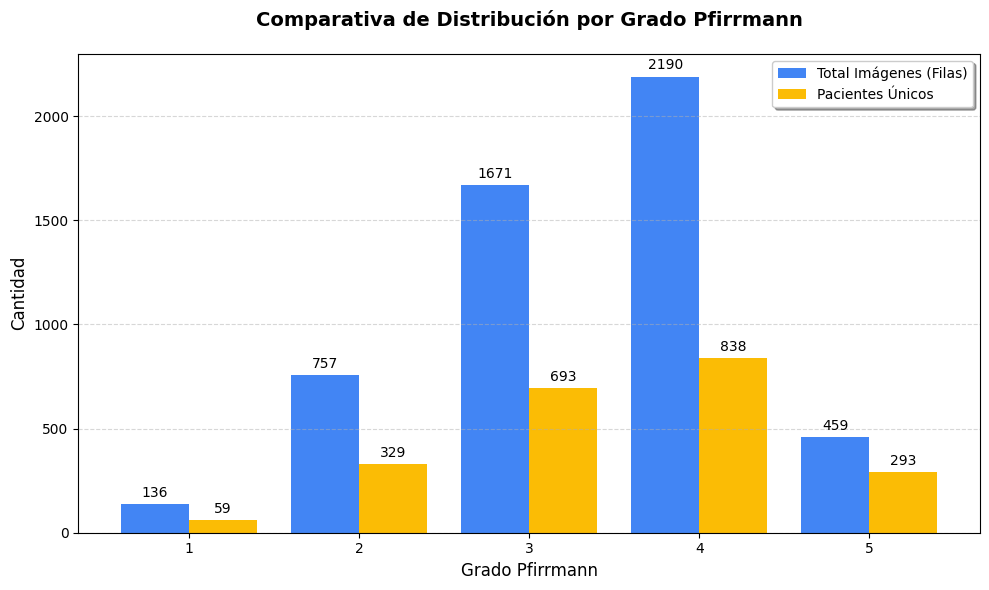

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos (Asegúrate de que la ruta es correcta en tu entorno)
# --- LIMPIEZA ---
df['Pfirrmann'] = df['Pfirrmann'].astype(str).str.strip().str.replace(',', '.', regex=False)
df['Pfirrmann'] = pd.to_numeric(df['Pfirrmann'], errors='coerce')
df = df.dropna(subset=['Pfirrmann'])
df['Pfirrmann'] = df['Pfirrmann'].round().astype(int)

# --- EL DETECTIVE ---
# 1. Contar cuántas FILAS (imágenes) hay por grado
total_imagenes = df['Pfirrmann'].value_counts().sort_index()

# 2. Contar cuántos PACIENTES (sujetos) hay por grado
total_pacientes = df.groupby('Pfirrmann')['patient_id'].nunique().sort_index()

# 3. Crear una tabla comparativa
comparativa = pd.DataFrame({
    'Total Imágenes': total_imagenes,
    'Pacientes Únicos': total_pacientes
})

print("TABLA COMPARATIVA:")
print(comparativa)

# --- GENERACIÓN DE LA GRÁFICA ---
# Configuramos el estilo y los colores
ax = comparativa.plot(kind='bar', figsize=(10, 6), color=['#4285F4', '#FBBC05'], width=0.8)

plt.title('Comparativa de Distribución por Grado Pfirrmann', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Grado Pfirrmann', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Total Imágenes (Filas)', 'Pacientes Únicos'], frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de datos sobre cada barra para facilitar la lectura
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()
plt.savefig('grafica_comparativa_pfirrmann.png')

In [14]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version PyTorch was built with: {torch.version.cuda}")

PyTorch version: 2.5.1+cu121
Is CUDA available: False
CUDA version PyTorch was built with: 12.1


/mnt/datalake/openmind/MedP-Midas/venv/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA driver initialization failed, you might not have a CUDA gpu. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


--- CANTIDAD DE DISCOS POR GRADO DE PFIRRMANN ---
           Discos Dataset 1  Discos Dataset 2
Pfirrmann                                    
1                        68               136
2                       509               757
3                      1348              1671
4                      1447              2190
5                       213               459


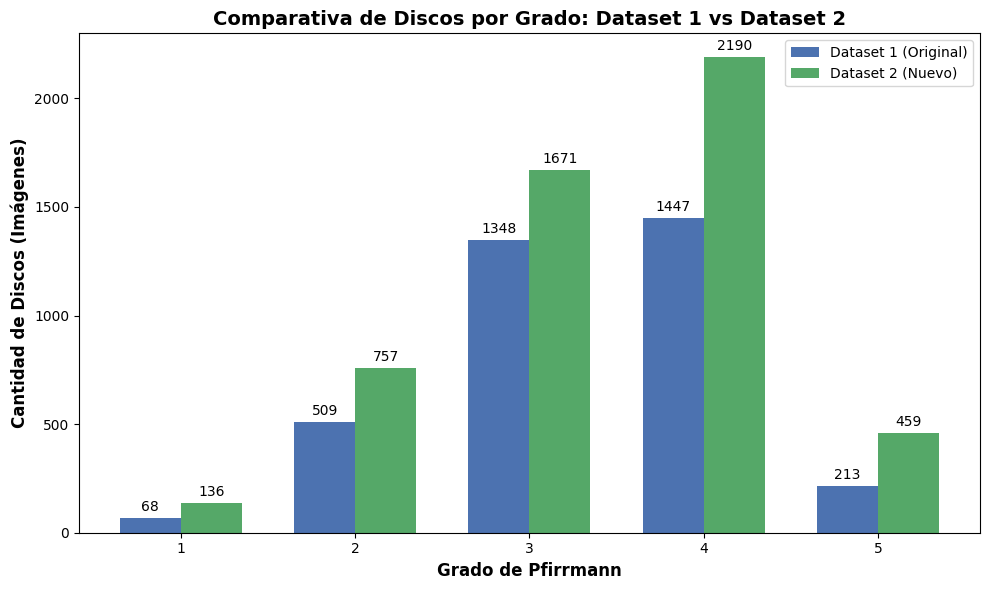

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PROCESAR DATASET 1 (Formato Largo)
# ==========================================
# Reemplaza con la ruta de tu primer CSV
ruta_csv_1 = '/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/data/filtered_midas900_t2w_partition.csv'
df1 = pd.read_csv(ruta_csv_1)

# Transformación (Melt) para tener 1 fila por disco
df1_long = pd.melt(
    df1, 
    id_vars=['Subject_MIDS'],               
    value_vars=['1', '2', '3', '4', '5'],   
    var_name='Disco',                       
    value_name='Pfirrmann'                  
)

# Limpieza (misma lógica)
df1_long['Pfirrmann'] = df1_long['Pfirrmann'].astype(str).str.strip().str.replace(',', '.', regex=False)
df1_long['Pfirrmann'] = pd.to_numeric(df1_long['Pfirrmann'], errors='coerce')
df1_long = df1_long.dropna(subset=['Pfirrmann'])
df1_long['Pfirrmann'] = df1_long['Pfirrmann'].round().astype(int)

# Contar DISCOS por grado
discos_ds1 = df1_long['Pfirrmann'].value_counts().sort_index()



# ==========================================
# 2. PROCESAR DATASET 2 (Formato Ancho)
# ==========================================
# Reemplaza con la ruta de tu nuevo CSV
ruta_csv_2 = '/mnt/datalake/openmind/MedP-Midas/sgonzalez/DL/DL/data/updated_patients_per_discs.csv'
df2 = pd.read_csv(ruta_csv_2)

# Limpieza
df2['Pfirrmann'] = df2['Pfirrmann'].astype(str).str.strip().str.replace(',', '.', regex=False)
df2['Pfirrmann'] = pd.to_numeric(df2['Pfirrmann'], errors='coerce')
df2 = df2.dropna(subset=['Pfirrmann'])
df2['Pfirrmann'] = df2['Pfirrmann'].round().astype(int)

# Contar DISCOS por grado
discos_ds2 = df2['Pfirrmann'].value_counts().sort_index()



# ==========================================
# 3. CREAR TABLA CONJUNTA E IMPRIMIR
# ==========================================
# Unimos las dos series en un solo DataFrame
comparativa_discos = pd.DataFrame({
    'Discos Dataset 1': discos_ds1,
    'Discos Dataset 2': discos_ds2
}).fillna(0).astype(int) # Llenamos con 0 si algún grado no existe en un dataset

print("--- CANTIDAD DE DISCOS POR GRADO DE PFIRRMANN ---")
print(comparativa_discos)


# ==========================================
# 4. GRAFICAR COMPARATIVA
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparativa_discos.index))  # Grados (1, 2, 3, 4, 5)
width = 0.35  # Ancho de las barras

# Crear las barras para cada dataset
barras_ds1 = ax.bar(x - width/2, comparativa_discos['Discos Dataset 1'], width, 
                    label='Dataset 1 (Original)', color='#4C72B0')
barras_ds2 = ax.bar(x + width/2, comparativa_discos['Discos Dataset 2'], width, 
                    label='Dataset 2 (Nuevo)', color='#55A868')

# Personalización del gráfico
ax.set_xlabel('Grado de Pfirrmann', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Discos (Imágenes)', fontsize=12, fontweight='bold')
ax.set_title('Comparativa de Discos por Grado: Dataset 1 vs Dataset 2', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparativa_discos.index)
ax.legend()

# Función para poner los numeritos encima de cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(barras_ds1)
autolabel(barras_ds2)

# Ajustar y guardar
plt.tight_layout()
plt.savefig('comparativa_discos_datasets.png', dpi=300)
# plt.show() # Descomentar si usas Jupyter Notebook

In [ ]:
###NUEVOS + ANTIGUOS PACIENTES
# Cargar datos
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/data/new_input_data.csv')

# --- LIMPIEZA (Igual que antes) ---
df['Pfirrmann'] = df['Pfirrmann'].astype(str).str.strip().str.replace(',', '.', regex=False)
df['Pfirrmann'] = pd.to_numeric(df['Pfirrmann'], errors='coerce')
df = df.dropna(subset=['Pfirrmann'])
df['Pfirrmann'] = df['Pfirrmann'].round().astype(int)

# --- EL DETECTIVE ---
# 1. Contar cuántas FILAS (imágenes) hay por grado
total_imagenes = df['Pfirrmann'].value_counts().sort_index()

# 2. Contar cuántos PACIENTES (sujetos) hay por grado
total_pacientes = df.groupby('Pfirrmann')['subj'].nunique().sort_index()

# 3. Crear una tabla comparativa
comparativa = pd.DataFrame({
    'Total Imágenes (Filas)': total_imagenes,
    'Pacientes Únicos': total_pacientes
})

print("TABLA COMPARATIVA:")
print(comparativa)



TABLA COMPARATIVA:
           Total Imágenes (Filas)  Pacientes Únicos
Pfirrmann                                          
1                             138                59
2                             758               327
3                            1669               692
4                            2189               836
5                             458               292


In [3]:
import pandas as pd

def analizar_datos(file_path):
    df = pd.read_csv(file_path)
    
    # Conteo de pacientes
    total_p = df['Subject_XNAT'].nunique()
    total_r = len(df)
    
    print(f"RESUMEN GENERAL")
    print(f"==============================")
    print(f"Total de pacientes únicos: {total_p}")
    print(f"Total de sesiones/filas:   {total_r}")
    print(f"==============================\n")

    # Mapeo de discos
    disc_mapping = {
        '1': 'L5-S1', '2': 'L4-L5', '3': 'L3-L4', '4': 'L2-L3', '5': 'L1-L2'
    }
    
    for col, label in disc_mapping.items():
        if col in df.columns:
            print(f"Conteo para {label} (Columna {col}):")
            print(df[col].value_counts().sort_index())
            print("-" * 30)

# Ejecutar
analizar_datos('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/data/filtered_midas900_t2w_partition.csv')

RESUMEN GENERAL
Total de pacientes únicos: 715
Total de sesiones/filas:   717

Conteo para L5-S1 (Columna 1):
1
1.0     13
2.0     38
3.0    193
4.0    380
5.0     93
Name: count, dtype: int64
------------------------------
Conteo para L4-L5 (Columna 2):
2
1.0     14
2.0     51
3.0    190
4.0    416
5.0     46
Name: count, dtype: int64
------------------------------
Conteo para L3-L4 (Columna 3):
3
1.0     19
2.0     91
3.0    300
4.0    284
5.0     23
Name: count, dtype: int64
------------------------------
Conteo para L2-L3 (Columna 4):
4
1.0     16
2.0    141
3.0    329
4.0    206
5.0     25
Name: count, dtype: int64
------------------------------
Conteo para L1-L2 (Columna 5):
5
1.0      6
2.0    188
3.0    336
4.0    161
5.0     26
Name: count, dtype: int64
------------------------------


In [4]:
import pandas as pd

# Cargar el archivo
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/data/filtered_midas900_t2w_partition.csv')

# Definir las columnas de los discos
columnas_discos = ['1', '2', '3', '4', '5']

# Seleccionar solo esas columnas y contar todos los valores combinados
# stack() junta todos los valores en una sola columna para contarlos
conteo_total = df[columnas_discos].stack().value_counts().sort_index()

print("CONTEO TOTAL DE VALORES EN TODOS LOS DISCOS")
print("===========================================")
for valor, frecuencia in conteo_total.items():
    print(f"Valor {valor}: se repite {int(frecuencia)} veces")

print("===========================================")
print(f"Suma total de observaciones: {int(conteo_total.sum())}")

CONTEO TOTAL DE VALORES EN TODOS LOS DISCOS
Valor 1.0: se repite 68 veces
Valor 2.0: se repite 509 veces
Valor 3.0: se repite 1348 veces
Valor 4.0: se repite 1447 veces
Valor 5.0: se repite 213 veces
Suma total de observaciones: 3585


In [ ]:
import pandas as pd

# 1. Cargar el archivo
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/data/filtered_midas900_t2w_partition.csv')

# 2. Definir las columnas de los discos
columnas_discos = ['1', '2', '3', '4', '5']

# 3. Reestructurar los datos (formato largo)
df_long = df.melt(id_vars=['Subject_XNAT'], value_vars=columnas_discos, 
                  value_name='Grado')

# 4. Agrupar por el Valor (Grado) y calcular los dos tipos de conteo
resumen = df_long.groupby('Grado')['Subject_XNAT'].agg(
    Conteos='count',             # Suma total de veces que aparece el valor
    Pacientes_Unicos='nunique'   # Cuántos pacientes distintos lo tienen
).reset_index()

# 5. Formatear la tabla final
resumen.columns = ['Valor (Disco)', 'Número de Conteos', 'Número de Pacientes']

print("TABLA FINAL DE RESULTADOS")
print("==================================================")
print(resumen.to_string(index=False))
print("==================================================")

TABLA FINAL DE RESULTADOS
 Valor (Disco)  Número de Conteos  Número de Pacientes
           1.0                 68                   38
           2.0                509                  249
           3.0               1348                  552
           4.0               1447                  606
           5.0                213                  160


In [6]:
import nibabel as nib
from sklearn.model_selection import train_test_split


In [14]:
# read csv in /mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/code/DL/final_input_data.csv
data = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/data/new_input_data.csv')

data['Pfirrmann'] = pd.to_numeric(data['Pfirrmann'], errors='coerce')
data['Pfirrmann'] = data['Pfirrmann']
data = data.dropna(subset=['Pfirrmann'])
data['Pfirrmann'] = data['Pfirrmann'].astype(int)
missing_files_count = 0

for path in data['disc_path'].tolist():
    try:
        img = nib.load(path)
        shape = img.shape
        

    except (FileNotFoundError, OSError):
        missing_files_count += 1
        #delete this patient in the data dataframe
        data = data[data['disc_path'] != path]
        continue

unique_patients = data['subj'].unique()
train_patients,val_patients = train_test_split(unique_patients,test_size=0.1,random_state=42)
train_df = data[data['subj'].isin(train_patients)]
val_df = data[data['subj'].isin(val_patients)]
train_files = [{"img": img, "label": label} for img, label in zip(train_df['disc_path'].values, train_df['Pfirrmann'].values)]


In [15]:
# Imprimir los primeros 5 elementos
print("\nPrimeros 5 elementos de train_files:")
for i in range(5):
    print(train_files[i])

# Para ver TODOS los valores únicos que tomó el label en train_files
labels_en_train = set(item['label'] for item in train_files)
print(f"\nValores únicos de 'label' en train_files: {sorted(list(labels_en_train))}")


Primeros 5 elementos de train_files:
{'img': '/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/cropped_discs_aligned/sub-S02/sub-S02_L1-L2.nii.gz', 'label': np.int64(2)}
{'img': '/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/cropped_discs_aligned/sub-S02/sub-S02_L2-L3.nii.gz', 'label': np.int64(2)}
{'img': '/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/cropped_discs_aligned/sub-S02/sub-S02_L3-L4.nii.gz', 'label': np.int64(2)}
{'img': '/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/cropped_discs_aligned/sub-S02/sub-S02_L4-L5.nii.gz', 'label': np.int64(2)}
{'img': '/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/cropped_discs_aligned/sub-S02/sub-S02_L5-S1.nii.gz', 'label': np.in